In [1]:
#Classify Banana [overripe, ripe, rotten, unripe]

In [ ]:
# 1. Import Dependecies
import pandas as pd
import os
from pathlib import Path
import numpy as np
import cv2
# Packages for visuals
import matplotlib.pyplot as plt
# Allows charts to appear in the notebook
%matplotlib inline
import pickle
from collections import Counter
# Optional but recommended for stronger SVM features
from skimage.feature import hog

In [ ]:
# 2. Global Config
ROOT = Path(".")
SPLITS = ["train", "valid", "test"]
CLASSES = ["overripe", "ripe", "rotten", "unripe"]

IMG_SIZE = (128, 128)   # keep fixed for SVM
USE_HOG = True   

In [ ]:
# 3. Dataset audit + cleaning checks
def list_images(folder):
    #allow any extensions
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return [p for p in folder.rglob("*") if p.suffix.lower() in exts]

def validate_image(path, min_side=20): #function to check if image is readable and not too small
    #load image
    img = cv2.imread(str(path))
    #treat as corrupt if not loading
    if img is None:
        return False, "unreadable"
    h, w = img.shape[:2]
    if h < min_side or w < min_side:
        return False, "too_small"
    return True, "ok"

rows = []
bad_files = [] #store invalid image

#validate every images
for split in SPLITS:
    for cls in CLASSES:
        folder = ROOT / split / cls
        if not folder.exists(): # if not folder
            rows.append({"split": split, "class": cls, "count": 0})
            continue
            
        imgs = list_images(folder) #get all images
        rows.append({"split": split, "class": cls, "count": len(imgs)}) #store image count
        
        for p in imgs:
            ok, reason = validate_image(p)
            if not ok:
                bad_files.append({"path": str(p), "reason": reason})

#list to dataframe to visualize the image quality and count
df_counts = pd.DataFrame(rows)
print("Image count per split/class:")
display(df_counts.pivot(index="class", columns="split", values="count").fillna(0).astype(int))

#show bad files detected
print(f"\nBad files found: {len(bad_files)}")
if bad_files:
    bad_df = pd.DataFrame(bad_files)
    display(bad_df["reason"].value_counts().to_frame("count"))
    display(bad_df.head(10))

Image count per split/class:


split,test,train,valid
class,,,
overripe,113,2349,229
ripe,154,3522,339
rotten,185,4020,388
unripe,110,1902,167



Bad files found: 0


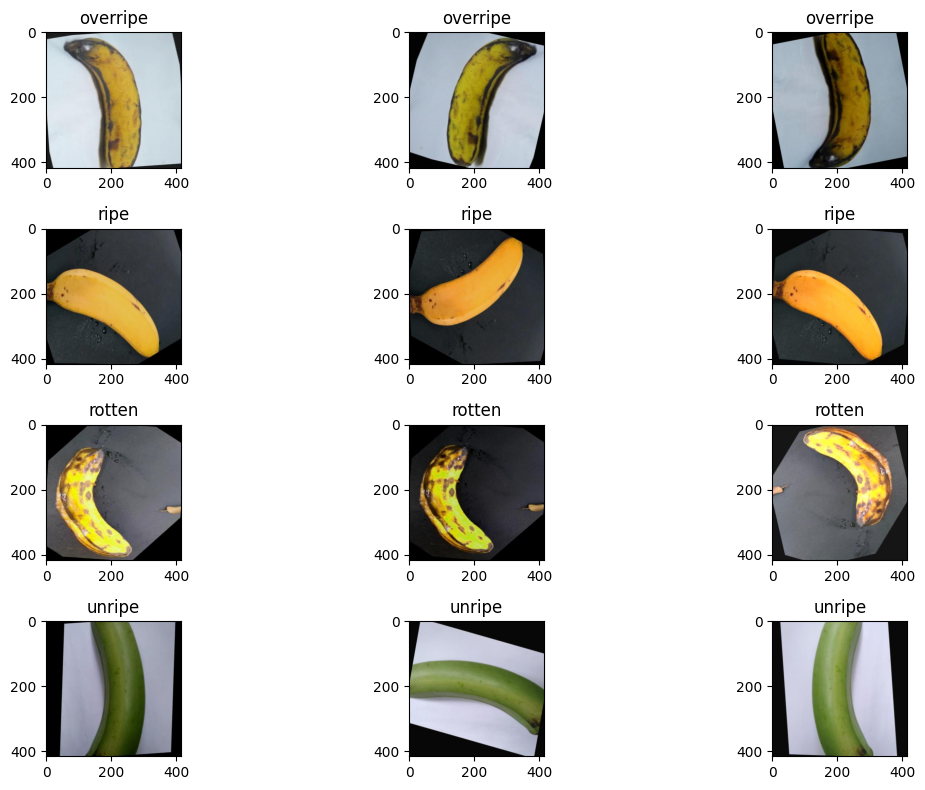

In [15]:
#show sample images

def show_sample_images(split="train", classes=CLASSES, root=ROOT, samples_per_class=3):
    """
    Display sample images per class.
    """
    plt.figure(figsize=(12, 8))                    

    idx = 1                                

    for cls in classes:                          
        folder = root / split / cls             

        if not folder.exists():                
            continue

        imgs = list_images(folder)              

        for i in range(min(samples_per_class, len(imgs))): 
            img = cv2.imread(str(imgs[i]))      

            if img is None:                 
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(len(classes), samples_per_class, idx)
            plt.imshow(img_rgb)                 
            plt.title(cls)                                 
            idx += 1                          
    plt.tight_layout()                           
    plt.show()                                   


# Call visualization
show_sample_images("train")                        # Show training samples

In [11]:
# 4. Load + preprocess for SVM (requirements)
def load_split_flattened(split, classes, root=ROOT, img_size=(32, 32)):
    X, y = [], []           # X - features, y - labels
    skipped = []            # skipped files

    for label, cls in enumerate(classes):
        folder = root / split / cls
        if not folder.exists():             # missing folder
            continue

        imgs = list_images(folder)          # get all images 
        for p in imgs:                      # for each image
            img = cv2.imread(str(p))
            if img is None:
                skipped.append((str(p), "unreadable")) #append unreadable file
                continue

            # a. Convert to grayscale
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # b. Resize image (option: 28x28 ))
            gray = cv2.resize(gray, img_size, interpolation=cv2.INTER_AREA)

            # c. Normalize pixel values to 0..1
            gray = gray.astype(np.float32) / 255.0

            # d. Flatten into 1D vector and Adding HOG features
            features = hog(                          # Compute HOG
                gray,                                # Input image
                orientations=9,                      # Number of gradient directions
                pixels_per_cell=(8, 8),              # Cell size
                cells_per_block=(2, 2),              # Block size
                block_norm='L2-Hys',                 # Normalization method
                visualize=False,                     # Do not return image
                feature_vector=True                  # Return as 1D vector
            )

            X.append(features)       # append cleaned feature images
            y.append(label)     # append cleaned label images



    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32), skipped

# Build datasets
X_train, y_train, skip_train = load_split_flattened("train", CLASSES, ROOT, img_size=(32, 32))
X_valid, y_valid, skip_valid = load_split_flattened("valid", CLASSES, ROOT, img_size=(32, 32))
X_test, y_test, skip_test = load_split_flattened("test", CLASSES, ROOT, img_size=(32, 32))

#print shape
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_valid:", X_valid.shape, "y_valid:", y_valid.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)
print("Total skipped:", len(skip_train) + len(skip_valid) + len(skip_test))

X_train: (11793, 324) y_train: (11793,)
X_valid: (1123, 324) y_valid: (1123,)
X_test : (562, 324) y_test : (562,)
Total skipped: 0
